In [213]:
import numpy as np

In [214]:
import pandas as pd

In [215]:
import seaborn as sns

In [216]:
import matplotlib.pyplot as plt

1) Loading the Taxis Dataset using the following code: 

In [217]:
df=sns.load_dataset("taxis")

In [218]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [219]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


2) Handling Missing Values  

In [220]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [221]:
df.duplicated().sum()

np.int64(0)

 For columns that are critical and cannot be reasonably imputed, remove rows with 
missing values to maintain data integrity. 

cosidering  coloum "pickup_zone" as critical. so removing its rows which has missing values

In [222]:
#cosidering  coloum "pickup_zone" as critical. so removing its rows which has missing values
df.dropna(subset=["pickup_zone"],inplace=True)

df.info()

<class 'pandas.DataFrame'>
Index: 6407 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6407 non-null   datetime64[us]
 1   dropoff          6407 non-null   datetime64[us]
 2   passengers       6407 non-null   int64         
 3   distance         6407 non-null   float64       
 4   fare             6407 non-null   float64       
 5   tip              6407 non-null   float64       
 6   tolls            6407 non-null   float64       
 7   total            6407 non-null   float64       
 8   color            6407 non-null   str           
 9   payment          6364 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6383 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6383 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)
memor

In [223]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            43
pickup_zone         0
dropoff_zone       24
pickup_borough      0
dropoff_borough    24
dtype: int64

Check for missing values in the dataset and identify columns with missing data.   Impute missing values using appropriate strategies based on the column type (e.g., 
using the mean, median, or mode for numerical columns and the mode for categorical 
columns). 

In [224]:
cat_cols=df.select_dtypes(include='str').columns
cat_cols

Index(['color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='str')

In [225]:
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])


In [226]:
num_cols=df.select_dtypes(include=np.number).columns
num_cols

Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='str')

In [227]:
for cols in num_cols:
    df[cols]=df[cols].fillna(df[cols].mean())

After cleaning

In [228]:
df.info()

<class 'pandas.DataFrame'>
Index: 6407 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6407 non-null   datetime64[us]
 1   dropoff          6407 non-null   datetime64[us]
 2   passengers       6407 non-null   int64         
 3   distance         6407 non-null   float64       
 4   fare             6407 non-null   float64       
 5   tip              6407 non-null   float64       
 6   tolls            6407 non-null   float64       
 7   total            6407 non-null   float64       
 8   color            6407 non-null   str           
 9   payment          6407 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6407 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6407 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)
memor

In [229]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [230]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='str')

3) Visualizations using Matplotlib/Pandas Plot:

★ Line Chart  
Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and 
fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.

In [231]:
print(df['pickup'].dtype)

datetime64[us]


In [232]:
df['pickup']=pd.to_datetime(df['pickup'])
df['pickup']

0      2019-03-23 20:21:09
1      2019-03-04 16:11:55
2      2019-03-27 17:53:01
3      2019-03-10 01:23:59
4      2019-03-30 13:27:42
               ...        
6428   2019-03-31 09:51:53
6429   2019-03-31 17:38:00
6430   2019-03-23 22:55:18
6431   2019-03-04 10:09:25
6432   2019-03-13 19:31:22
Name: pickup, Length: 6407, dtype: datetime64[us]

In [233]:
df['pickup']=df['pickup'].dt.date


In [234]:
df['pickup']

0       2019-03-23
1       2019-03-04
2       2019-03-27
3       2019-03-10
4       2019-03-30
           ...    
6428    2019-03-31
6429    2019-03-31
6430    2019-03-23
6431    2019-03-04
6432    2019-03-13
Name: pickup, Length: 6407, dtype: object

In [235]:

pickup_fare=df.groupby('pickup')['fare'].mean().reset_index()
pickup_fare

,pickup,fare
0,2019-02-28,5.000000
1,2019-03-01,12.299038
2,2019-03-02,11.909091
3,2019-03-03,12.993393
4,2019-03-04,13.659298
5,2019-03-05,13.763026
6,2019-03-06,12.733203
7,2019-03-07,13.296514
8,2019-03-08,13.489316
9,2019-03-09,13.443317


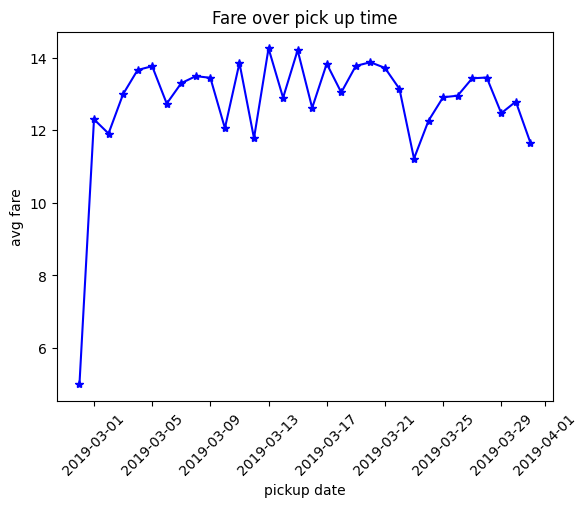

In [236]:
plt.Figure(figsize=(25,5))
plt.plot(pickup_fare['pickup'],pickup_fare['fare'],marker='*',color='b')

plt.title('Fare over pick up time')
plt.xlabel('pickup date')
plt.ylabel('avg fare')
plt.xticks(rotation=45)
plt.show()

★ Bar Chart  
Create a bar chart to show the total fare for each pickup_borough. Group the data by 
pickup_borough and sum the fare for each group.  

In [237]:
fare_sum=df.groupby('pickup_borough')['fare'].sum().reset_index()
fare_sum

,pickup_borough,fare
0,Bronx,2078.91
1,Brooklyn,6327.48
2,Manhattan,58753.42
3,Queens,16382.06


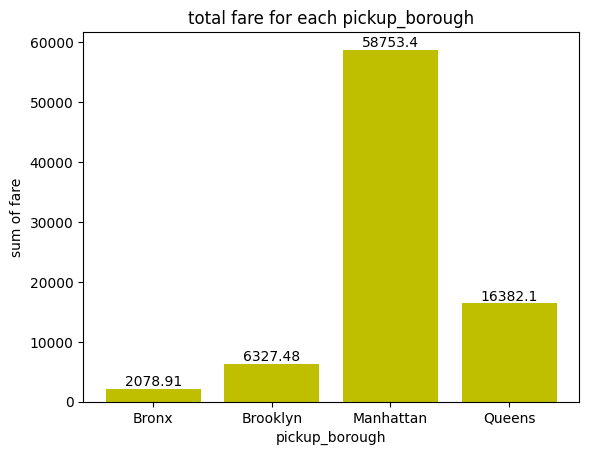

In [238]:
plt.Figure(figsize=(16,5))
bars=plt.bar(fare_sum['pickup_borough'],fare_sum['fare'],color='y')
plt.bar_label(bars)
plt.title('total fare for each pickup_borough')
plt.xlabel('pickup_borough')
plt.ylabel('sum of fare')
plt.show()

★ Pie Chart  
Plot a pie chart showing the distribution of trips based on the payment method (credit card, 
cash, etc.). Each slice should represent the count of trips for a specific payment method.  

In [239]:
payment_count =df.groupby('payment')['fare'].count().reset_index()
payment_count

,payment,fare
0,cash,1807
1,credit card,4600


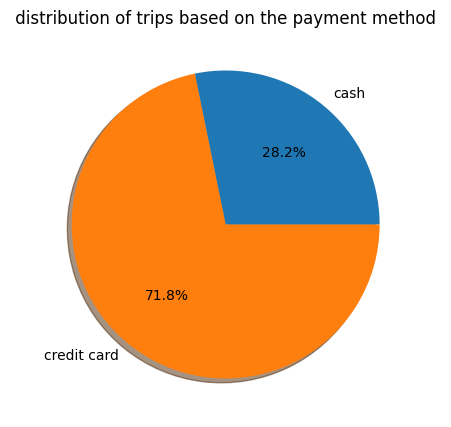

In [240]:
plt.figure(figsize=(16,5))
plt.pie(payment_count['fare'], labels=payment_count['payment'],autopct='%1.1f%%',shadow=True,)
plt.title(' distribution of trips based on the payment method ')
plt.show()

★ Histogram  
Create a histogram to visualize the distribution of distance. Customize the number of bins for 
better granularity and ensure the plot is easy to interpret. 

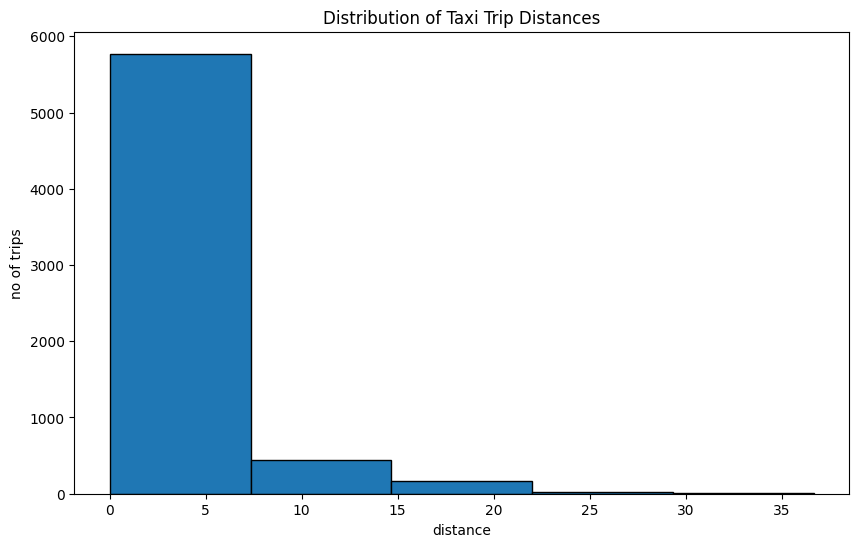

In [241]:
plt.figure(figsize=(10,6))
plt.hist(df['distance'],bins=5,edgecolor='black')
plt.title('Distribution of Taxi Trip Distances')
plt.xlabel('distance')
plt.ylabel('no of trips')
plt.show()

★ Box Plot  
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. Use 
pickup_borough as the categorical axis and tip as the numeric

In [242]:
tip_sum=df.groupby('pickup_borough')['tip'].sum().reset_index()
tip_sum

,pickup_borough,tip
0,Bronx,14.71
1,Brooklyn,370.11
2,Manhattan,10217.55
3,Queens,1997.32


In [243]:
pickup_borough_unique=df['pickup_borough'].unique()
pickup_borough_unique

<StringArray>
['Manhattan', 'Queens', 'Bronx', 'Brooklyn']
Length: 4, dtype: str

In [244]:
data_to_plt=[df[df['pickup_borough']==pick]['tip'] for pick in pickup_borough_unique]

C:\Users\venkatesan g\AppData\Local\Temp\ipykernel_4660\206842706.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plt,labels=pickup_borough_unique)


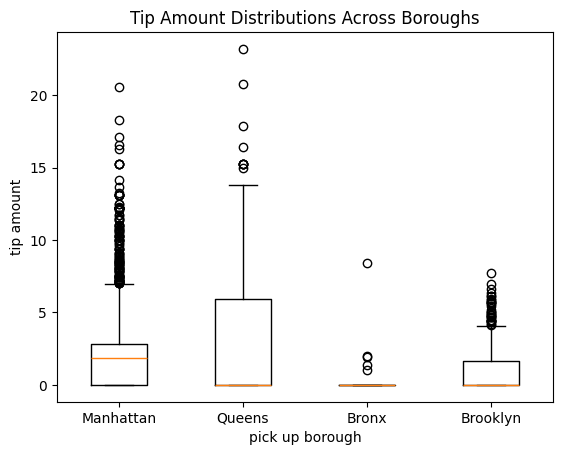

In [245]:
plt.boxplot(data_to_plt,labels=pickup_borough_unique)
plt.title('Tip Amount Distributions Across Boroughs')
plt.xlabel('pick up borough')
plt.ylabel('tip amount')
plt.show()

Visualizations using Seaborn:  

★ Count Plot  
Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should 
represent the boroughs, and the y-axis should show the count of trips

In [246]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='str')

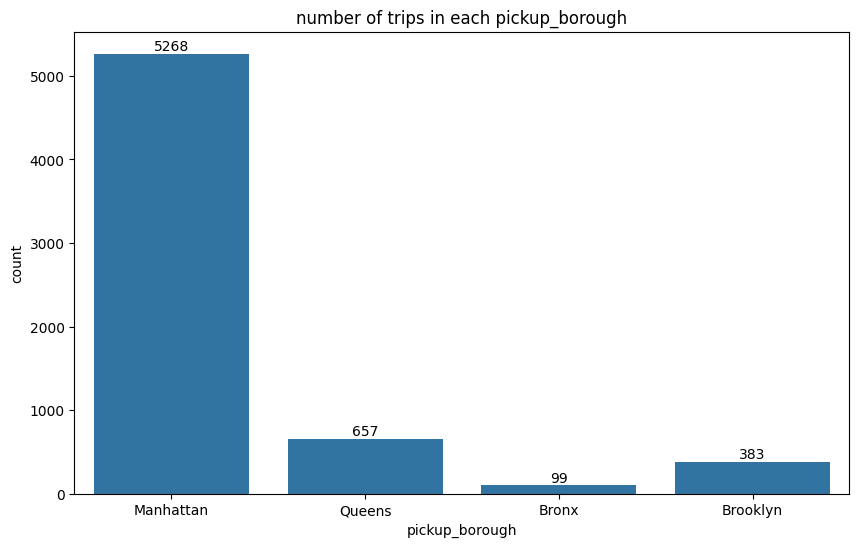

In [247]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df,x='pickup_borough')
ax.bar_label(ax.containers[0])
plt.title('number of trips in each pickup_borough')
plt.show()

★ Scatter Plot  
Plot a scatterplot to show the relationship between distance and fare. Use distance on the 
x-axis and fare on the y-axis to visualize any correlation. Color the points based on the 
pickup_borough to differentiate the trips by their respective boroughs.

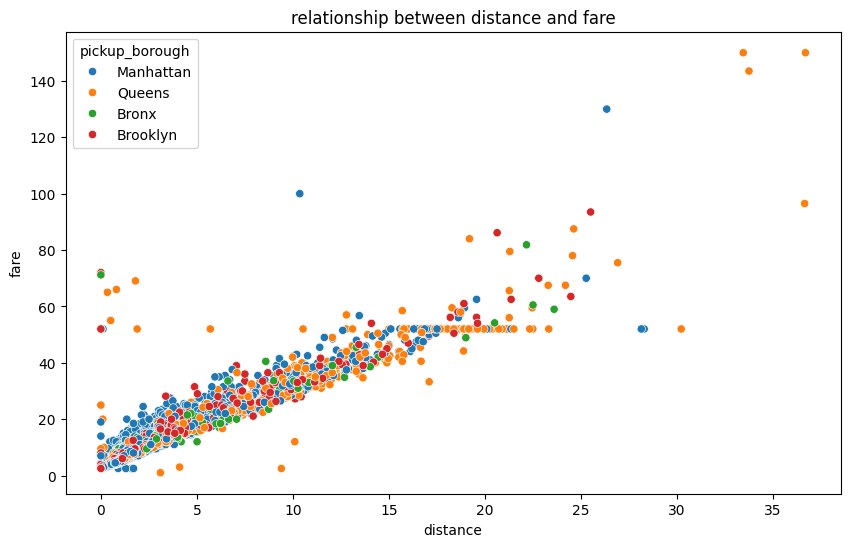

In [248]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='distance',y='fare', hue='pickup_borough')
plt.title('relationship between distance and fare')
plt.show()

★ Heatmap  
Plot a heatmap to visualize the correlation between numerical variables such as distance, fare, 
tip, tolls, and total. Use a correlation matrix to highlight the relationships.  

In [249]:
correlation_matrix=df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
correlation_matrix

,distance,fare,tip,tolls,total
distance,1.000000,0.938783,0.463935,0.639339,0.924426
fare,0.938783,1.000000,0.469023,0.609828,0.973744
tip,0.463935,0.469023,1.000000,0.405218,0.631109
tolls,0.639339,0.609828,0.405218,1.000000,0.684341
total,0.924426,0.973744,0.631109,0.684341,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

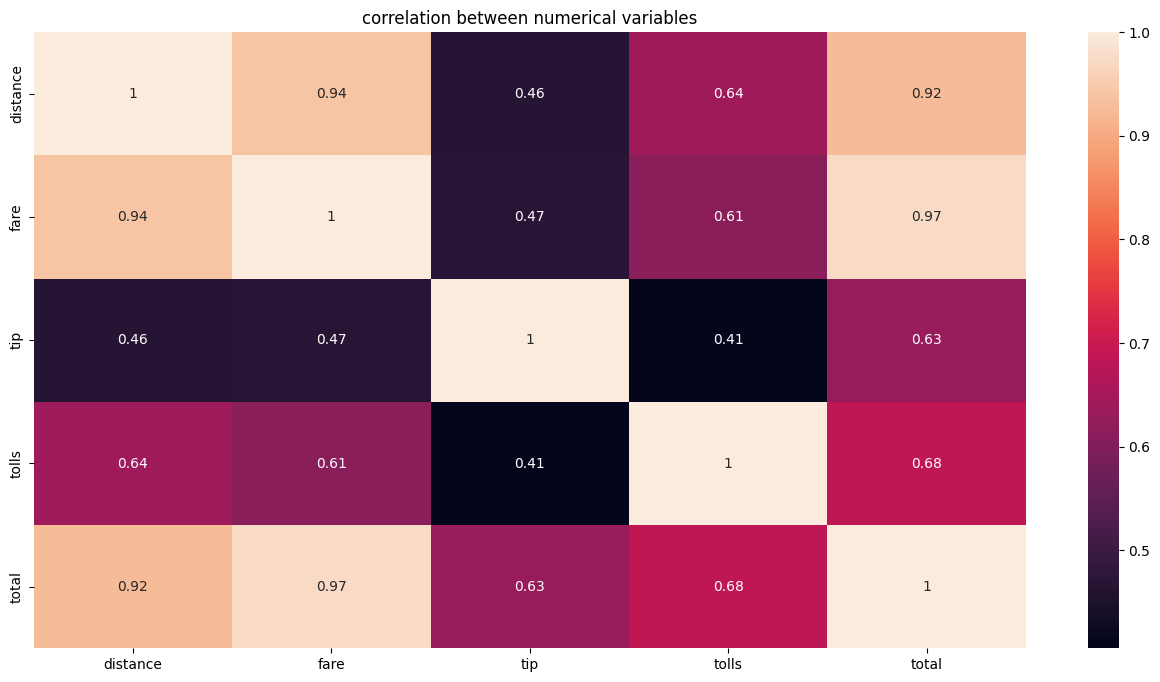

In [250]:
plt.figure(figsize=(16,8))
sns.heatmap(correlation_matrix,annot=True)
plt.title('correlation between numerical variables')
plt.show

★ Pair Plot  
Create a pair plot to visualize the pairwise relationships between distance, fare, tip, and total. 
Color the data points according to the pickup_zone column. to compare how different zones 
affect these variables. 

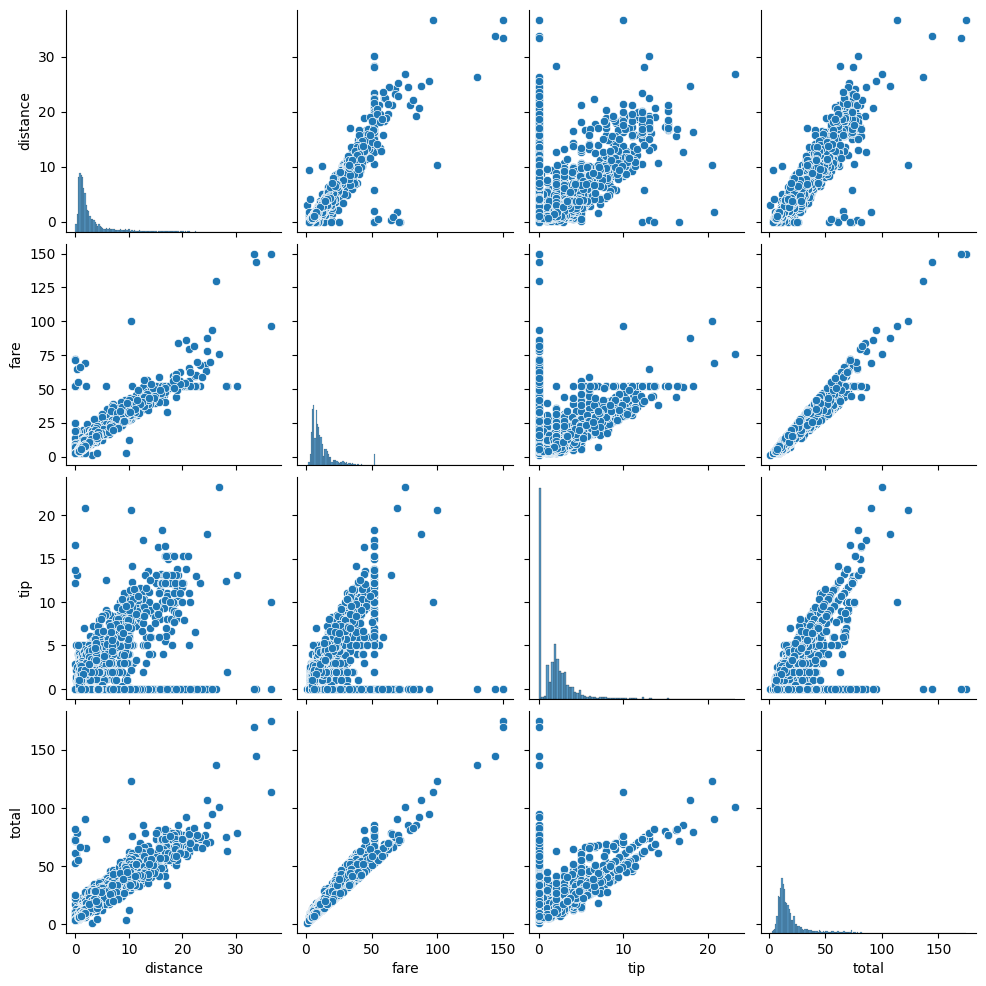

In [251]:
sns.pairplot(data=df,vars=['distance','fare','tip','total'])
plt.show()

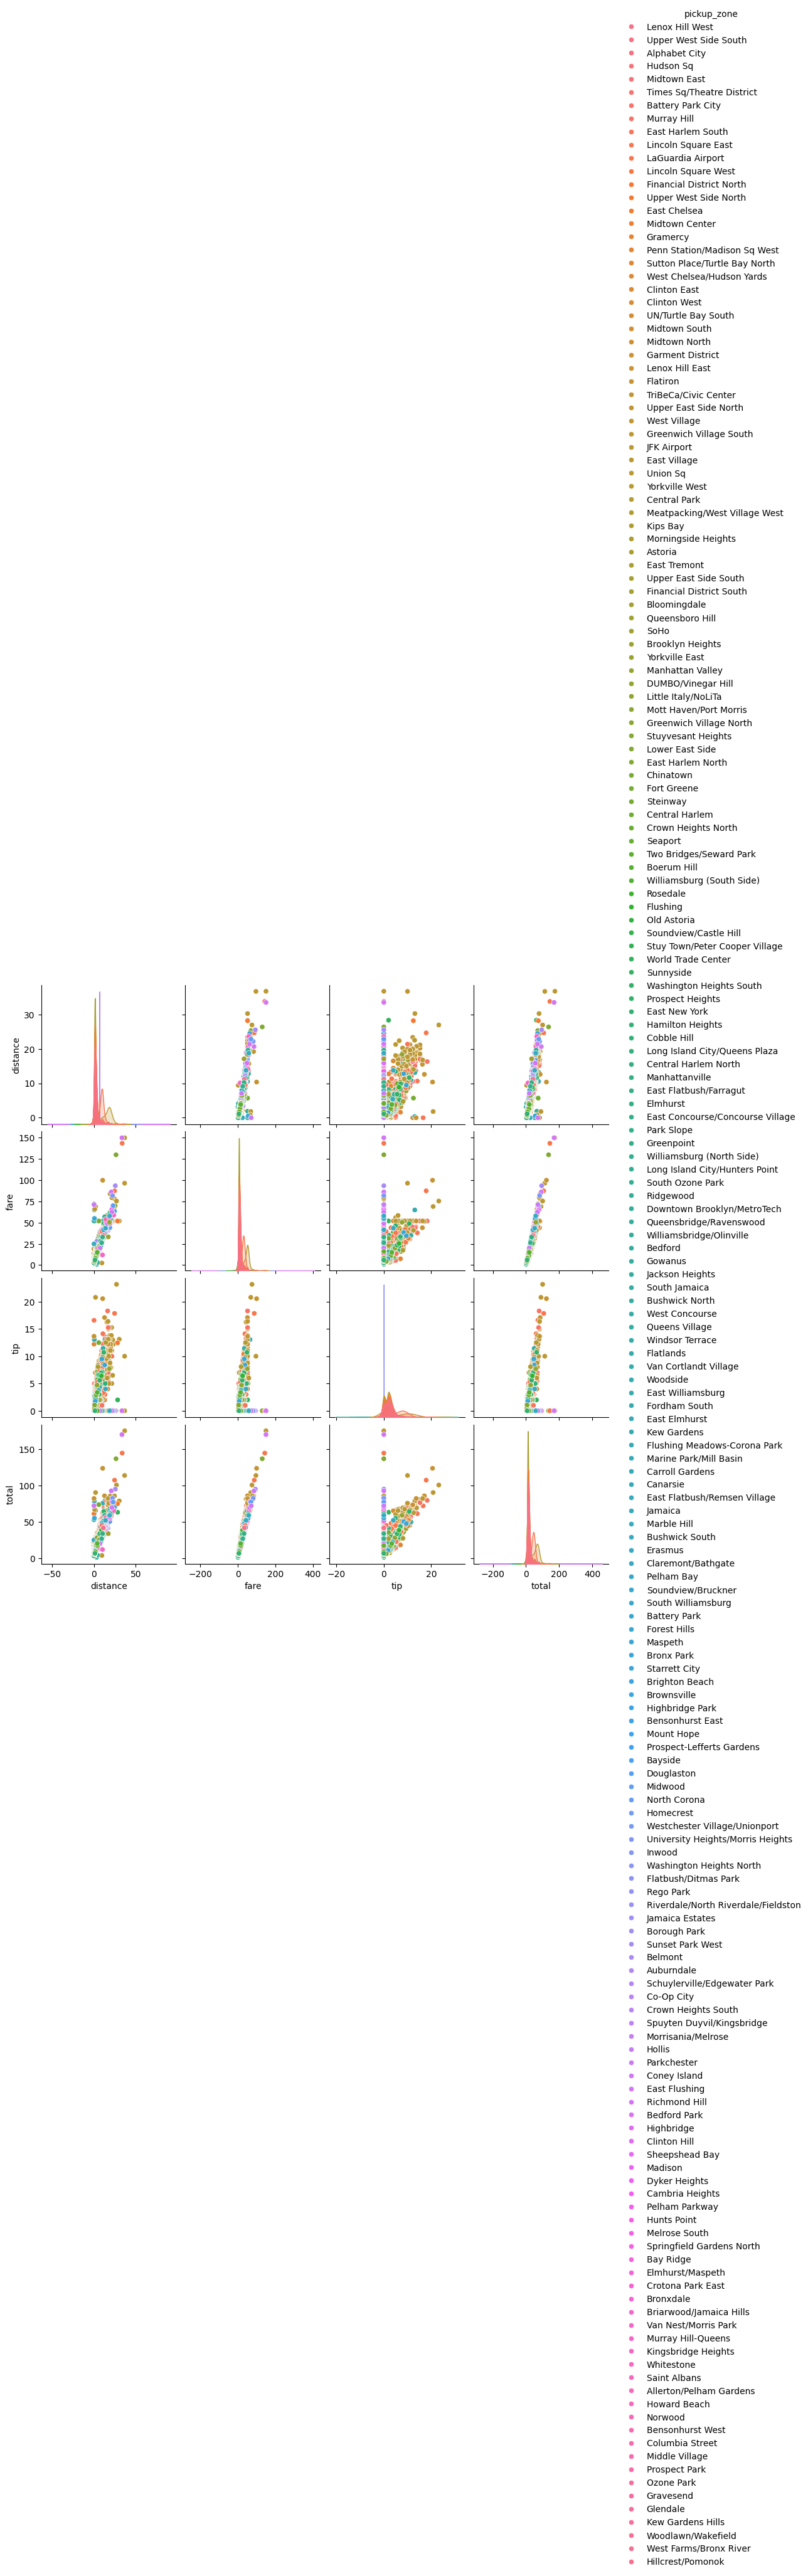

In [252]:
sns.pairplot(data=df,vars=['distance','fare','tip','total'],hue='pickup_zone')
plt.show()

In [253]:
# since pickup_zone has many unique values, legend become unreadable
# so filtering it its value counts and taking  the highest counts to show in plot

df['pickup_zone'].value_counts()

pickup_zone
Midtown Center                  230
Upper East Side South           211
Penn Station/Madison Sq West    210
Clinton East                    208
Midtown East                    198
                               ... 
Ozone Park                        1
Glendale                          1
Woodlawn/Wakefield                1
West Farms/Bronx River            1
Hillcrest/Pomonok                 1
Name: count, Length: 194, dtype: int64

In [254]:
df['pickup_zone'].value_counts().nlargest(10)

pickup_zone
Midtown Center                  230
Upper East Side South           211
Penn Station/Madison Sq West    210
Clinton East                    208
Midtown East                    198
Upper East Side North           186
Times Sq/Theatre District       184
Union Sq                        180
Lincoln Square East             177
Murray Hill                     162
Name: count, dtype: int64

In [255]:
top_zones=df['pickup_zone'].value_counts().nlargest(10).index
df_filtered=df[df['pickup_zone'].isin(top_zones)]
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 1946 entries, 4 to 6312
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           1946 non-null   object        
 1   dropoff          1946 non-null   datetime64[us]
 2   passengers       1946 non-null   int64         
 3   distance         1946 non-null   float64       
 4   fare             1946 non-null   float64       
 5   tip              1946 non-null   float64       
 6   tolls            1946 non-null   float64       
 7   total            1946 non-null   float64       
 8   color            1946 non-null   str           
 9   payment          1946 non-null   str           
 10  pickup_zone      1946 non-null   str           
 11  dropoff_zone     1946 non-null   str           
 12  pickup_borough   1946 non-null   str           
 13  dropoff_borough  1946 non-null   str           
dtypes: datetime64[us](1), float64(5), int64(1), object(1), s

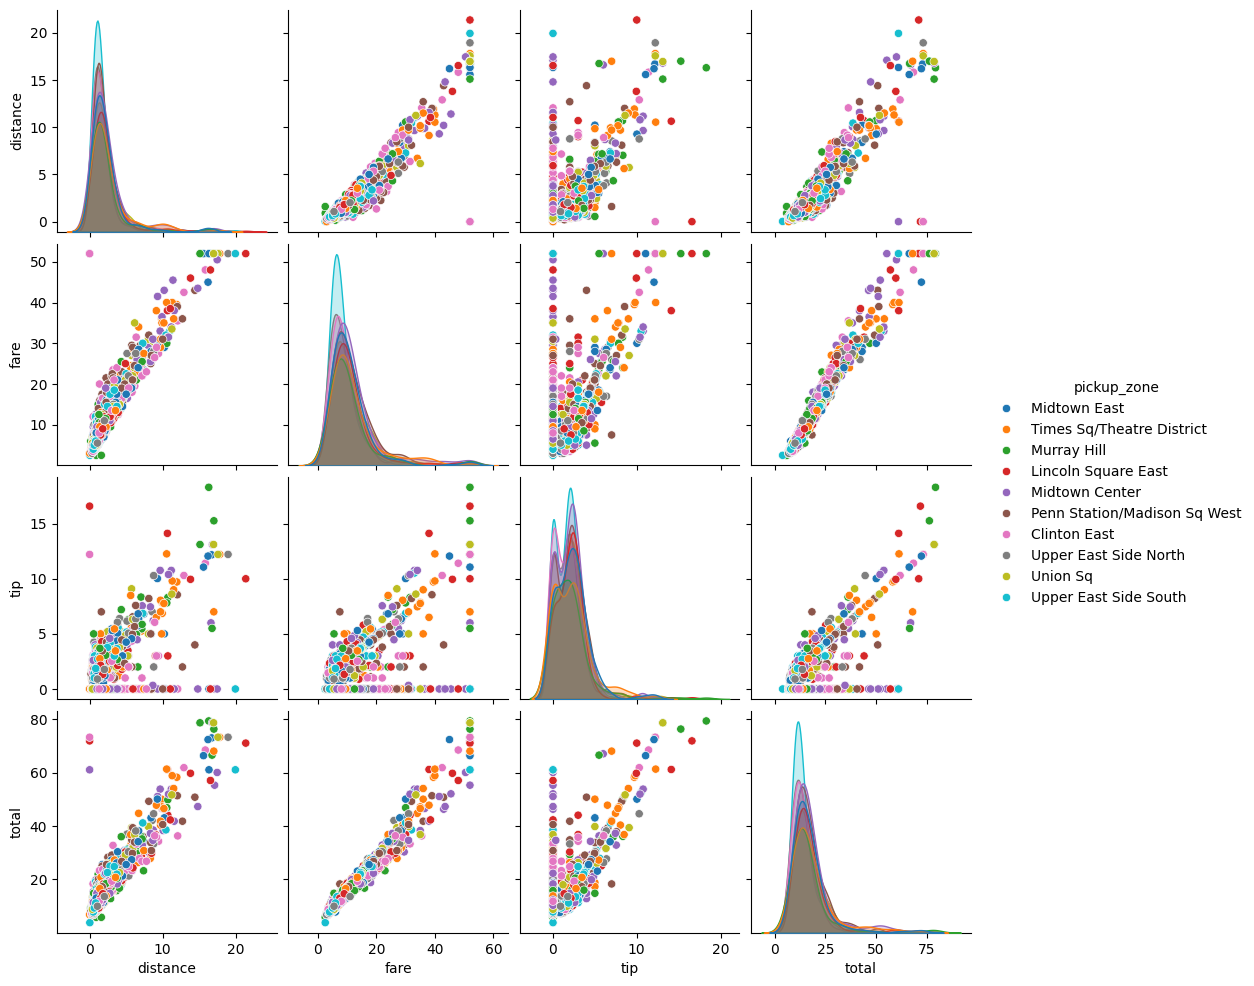

In [256]:
sns.pairplot(data=df_filtered,vars=['distance','fare','tip','total'],hue='pickup_zone')
plt.show()

★ Violin Plot  
Plot a violin plot to show the distribution of fare for each payment method. Use the payment 
method as the categorical axis and fare as the numeric axis to visualize its distribution.

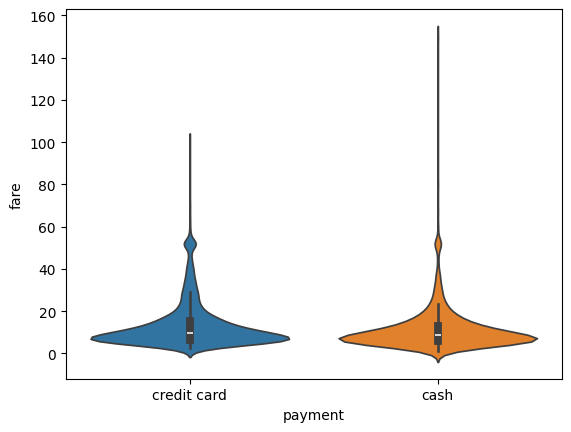

In [257]:

sns.violinplot(data=df,x='payment',y='fare',hue='payment')
plt.show()